# Clang vs GCC vs GPU Compiler/Hardware Comparison — IQ-TREE3 Benchmark Analysis (2026-05-08)

This notebook compares IQ-TREE3 performance across:
- **Clang** (`build-clang-vanila`) — new results from `2026_05_08_clang_outputs`
- **GCC** (`build-vanila`) — CPU results from `2026_05_04_testing_gpus`
- **GPU (OpenACC)** — V100, A100, H200 results from `2026_05_04_testing_gpus`

**CPU Configurations:** 1 thread (vanilla), 10 threads (OMP_10), 48 threads (OMP_48)  
**GPU Configurations:** V100 (32 GB), A100 (80 GB), H200 (141 GB)  
**Sequence lengths:** 10K, 100K, 1M  
**Data types:** AA (protein, LG+I+G4) and DNA (GTR+I+G4)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import re
import glob
import os

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

# Define all configs and their colors (used across multiple figures)
config_specs = [
    ('Clang 1T',   'Clang',    'VANILA',    '#90CAF9'),
    ('Clang 10T',  'Clang',    'OMP_10',    '#42A5F5'),
    ('Clang 48T',  'Clang',    'OMP_48',    '#1565C0'),
    ('GCC 1T',     'GCC',      'VANILA',    '#FFCC80'),
    ('GCC 10T',    'GCC',      'OMP_10',    '#FFA726'),
    ('GCC 48T',    'GCC',      'OMP_48',    '#E65100'),
    ('GPU V100',   'GPU_V100', 'GPU_V100',  '#81C784'),
    ('GPU A100',   'GPU_A100', 'GPU_A100',  '#43A047'),
    ('GPU H200',   'GPU_H200', 'GPU_H200',  '#1B5E20'),
]

def fmt_time(minutes):
    """Format minutes as human-readable h/m string."""
    if minutes is None or np.isnan(minutes):
        return ''
    total_min = round(minutes)
    if total_min < 1:
        return f'{minutes*60:.0f}s'
    elif total_min < 60:
        return f'{total_min}m'
    else:
        h = total_min // 60
        m = total_min % 60
        return f'{h}h{m:02d}m' if m > 0 else f'{h}h'

## 1. Parse Clang log files

In [2]:
def parse_iqtree_log(filepath):
    """Parse an IQ-TREE log file and extract key metrics."""
    with open(filepath, 'r') as f:
        content = f.read()
    
    result = {'path': filepath, 'filename': os.path.basename(filepath)}
    
    # Total wall-clock time
    m = re.search(r'Total wall-clock time used:\s+([\d.]+)\s+sec', content)
    result['wall_total_sec'] = float(m.group(1)) if m else None
    
    # Total CPU time
    m = re.search(r'Total CPU time used:\s+([\d.]+)\s+sec', content)
    result['cpu_total_sec'] = float(m.group(1)) if m else None
    
    # Tree search wall time
    m = re.search(r'Wall-clock time used for tree search:\s+([\d.]+)\s+sec', content)
    result['wall_treesearch_sec'] = float(m.group(1)) if m else None
    
    # Tree search CPU time
    m = re.search(r'CPU time used for tree search:\s+([\d.]+)\s+sec', content)
    result['cpu_treesearch_sec'] = float(m.group(1)) if m else None
    
    # Best log-likelihood
    m = re.search(r'BEST SCORE FOUND\s*:\s*([-\d.]+)', content)
    result['best_lnl'] = float(m.group(1)) if m else None
    
    # Iterations
    m = re.search(r'Total number of iterations:\s+(\d+)', content)
    result['iterations'] = int(m.group(1)) if m else None
    
    # Kernel info (thread count)
    m = re.search(r'Kernel:\s+(.+)', content)
    result['kernel'] = m.group(1).strip() if m else None
    
    # Host
    m = re.search(r'Host:\s+(\S+)', content)
    result['host'] = m.group(1).strip() if m else None
    
    # Sequences and columns
    m = re.search(r'Alignment has (\d+) sequences with (\d+) columns, (\d+) distinct patterns', content)
    if m:
        result['sequences'] = int(m.group(1))
        result['columns'] = int(m.group(2))
        result['patterns'] = int(m.group(3))
    
    # Command
    m = re.search(r'Command:\s+(.+)', content)
    result['command'] = m.group(1).strip() if m else None
    
    # Determine completion status
    result['completed'] = result['wall_total_sec'] is not None
    
    return result

# Parse all clang log files
clang_base = '/Users/u7826985/Projects/Nvidia/results/2026_05_08_clang_outputs'
clang_records = []

for data_type in ['AA', 'DNA']:
    log_dir = os.path.join(clang_base, data_type)
    for logfile in sorted(glob.glob(os.path.join(log_dir, '*.log'))):
        rec = parse_iqtree_log(logfile)
        rec['data_type'] = data_type
        rec['compiler'] = 'Clang'
        
        # Extract thread config from filename
        fname = rec['filename']
        if 'OMP_48' in fname or 'OMP48' in fname:
            rec['exec_type'] = 'OMP_48'
            rec['threads'] = 48
        elif 'OMP_10' in fname or 'OMP10' in fname:
            rec['exec_type'] = 'OMP_10'
            rec['threads'] = 10
        else:
            rec['exec_type'] = 'VANILA'
            rec['threads'] = 1
        
        # Extract length from filename
        if '1000000' in fname:
            rec['length'] = 1000000
        elif '100000' in fname:
            rec['length'] = 100000
        elif '10000' in fname:
            rec['length'] = 10000
        
        rec['model'] = 'LG+I+G4' if data_type == 'AA' else 'GTR+I+G4'
        clang_records.append(rec)

df_clang = pd.DataFrame(clang_records)
print(f"Parsed {len(df_clang)} Clang log files")
print(f"Completed: {df_clang['completed'].sum()}, Incomplete: {(~df_clang['completed']).sum()}")
df_clang[['data_type', 'exec_type', 'length', 'threads', 'wall_total_sec', 'best_lnl', 'completed']].sort_values(['data_type', 'length', 'exec_type'])

Parsed 18 Clang log files
Completed: 16, Incomplete: 2


,data_type,exec_type,length,threads,wall_total_sec,best_lnl,completed
5,AA,OMP_10,10000,10,827.765,-8.073500e+05,True
8,AA,OMP_48,10000,48,397.886,-8.073500e+05,True
2,AA,VANILA,10000,1,6217.484,-8.073500e+05,True
4,AA,OMP_10,100000,10,8611.117,-7.541977e+06,True
7,AA,OMP_48,100000,48,3407.967,-7.541977e+06,True
1,AA,VANILA,100000,1,69795.450,-7.541977e+06,True
3,AA,OMP_10,1000000,10,108943.917,-7.860520e+07,True
6,AA,OMP_48,1000000,48,50570.465,-7.860520e+07,True
0,AA,VANILA,1000000,1,NaN,NaN,False
14,DNA,OMP_10,10000,10,128.683,-5.642088e+05,True


## 2. Load GCC results from 2026_05_04 and filter comparable runs

In [3]:
df_all = pd.read_csv('/Users/u7826985/Projects/Nvidia/poc-gpu-likelihood-calculation_analysis/2026_05_04_testing_gpus/all_runs.csv')

# Filter GCC CPU-only runs with LG+I+G4 (AA) or GTR+I+G4 (DNA), matching exec types
gcc_filter = (
    (df_all['category'] == 'test_cases') &
    (df_all['model'].isin(['LG+I+G4', 'GTR+I+G4'])) &
    (df_all['exec_type'].isin(['VANILA', 'OMP_10', 'OMP_48'])) &
    (df_all['completed'] == True) &
    (df_all['length'].isin([10000, 100000, 1000000]))
)

df_gcc = df_all[gcc_filter].copy()
df_gcc['compiler'] = 'GCC'
df_gcc['threads'] = df_gcc['exec_type'].map({'VANILA': 1, 'OMP_10': 10, 'OMP_48': 48})

print(f"GCC runs matching criteria: {len(df_gcc)}")
df_gcc[['data_type', 'exec_type', 'length', 'threads', 'wall_total_sec', 'best_lnl', 'model']].sort_values(['data_type', 'length', 'exec_type'])

GCC runs matching criteria: 14


,data_type,exec_type,length,threads,wall_total_sec,best_lnl,model
99,AA,OMP_10,10000,10,1571.782,-8.073500e+05,LG+I+G4
100,AA,OMP_48,10000,48,658.140,-8.073500e+05,LG+I+G4
101,AA,VANILA,10000,1,11375.955,-8.073500e+05,LG+I+G4
102,AA,OMP_10,100000,10,12406.564,-7.541977e+06,LG+I+G4
103,AA,OMP_48,100000,48,4704.677,-7.541977e+06,LG+I+G4
111,DNA,OMP_10,10000,10,236.592,-5.642088e+05,GTR+I+G4
112,DNA,OMP_48,10000,48,295.288,-5.642088e+05,GTR+I+G4
113,DNA,VANILA,10000,1,898.374,-5.642088e+05,GTR+I+G4
114,DNA,OMP_10,100000,10,1429.376,-5.692985e+06,GTR+I+G4
115,DNA,OMP_48,100000,48,967.299,-5.692985e+06,GTR+I+G4


## 3. Load GPU results and build unified comparison DataFrame

In [4]:
# Load GPU (OpenACC) runs
gpu_filter = (
    (df_all['category'] == 'test_cases') &
    (df_all['model'].isin(['LG+I+G4', 'GTR+I+G4'])) &
    (df_all['exec_type'] == 'OPENACC') &
    (df_all['completed'] == True) &
    (df_all['length'].isin([10000, 100000, 1000000]))
)
df_gpu = df_all[gpu_filter].copy()
df_gpu['compiler'] = 'GPU_' + df_gpu['gpu'].astype(str)
df_gpu['threads'] = 1  # GPU runs use 1 CPU thread

print(f"GPU runs: {len(df_gpu)}")
print(df_gpu[['data_type', 'gpu', 'length', 'model', 'wall_total_sec', 'best_lnl']].sort_values(['data_type', 'length', 'gpu']).to_string())

# Combine all into a unified DataFrame
common_cols = ['data_type', 'exec_type', 'length', 'threads', 'compiler',
               'wall_total_sec', 'cpu_total_sec', 'wall_treesearch_sec',
               'best_lnl', 'iterations', 'completed', 'model', 'command']

# For GPU, set exec_type to GPU_<name> for clarity
df_gpu_fmt = df_gpu.copy()
df_gpu_fmt['exec_type'] = 'GPU_' + df_gpu_fmt['gpu'].astype(str)

df_combined = pd.concat([
    df_clang[df_clang['completed']][common_cols],
    df_gcc[common_cols],
    df_gpu_fmt[common_cols]
], ignore_index=True)

df_combined['wall_total_min'] = df_combined['wall_total_sec'] / 60
df_combined['wall_treesearch_min'] = df_combined['wall_treesearch_sec'] / 60
df_combined['length_label'] = df_combined['length'].map({10000: '10K', 100000: '100K', 1000000: '1M'})

# Create a friendly label for each config
def make_label(row):
    if row['compiler'].startswith('GPU_'):
        return row['compiler'].replace('GPU_', 'GPU ')
    thread_map = {'VANILA': '1T', 'OMP_10': '10T', 'OMP_48': '48T'}
    return f"{row['compiler']} {thread_map.get(row['exec_type'], row['exec_type'])}"

df_combined['config_label'] = df_combined.apply(make_label, axis=1)

print(f"\nCombined dataset: {len(df_combined)} runs")
df_combined.sort_values(['data_type', 'length', 'config_label'])[
    ['data_type', 'config_label', 'length_label', 'wall_total_min', 'wall_treesearch_min', 'best_lnl']
]

GPU runs: 14
   data_type   gpu   length     model  wall_total_sec      best_lnl
5         AA  A100    10000   LG+I+G4         741.859 -8.073500e+05
6         AA  H200    10000   LG+I+G4         377.020 -8.073500e+05
7         AA  V100    10000   LG+I+G4         593.847 -8.073500e+05
13        AA  H200   100000   LG+I+G4        1367.078 -7.541977e+06
14        AA  V100   100000   LG+I+G4        2905.543 -7.541977e+06
84       DNA  A100    10000  GTR+I+G4         646.964 -5.642088e+05
85       DNA  H200    10000  GTR+I+G4         275.252 -5.642088e+05
86       DNA  V100    10000  GTR+I+G4         393.366 -5.642088e+05
87       DNA  A100   100000  GTR+I+G4         958.752 -5.692985e+06
88       DNA  H200   100000  GTR+I+G4         516.057 -5.692985e+06
89       DNA  V100   100000  GTR+I+G4        1000.451 -5.692985e+06
90       DNA  A100  1000000  GTR+I+G4        4523.878 -5.920802e+07
91       DNA  H200  1000000  GTR+I+G4        2673.447 -5.920802e+07
92       DNA  V100  1000000  GTR+I+

,data_type,config_label,length_label,wall_total_min,wall_treesearch_min,best_lnl
4,AA,Clang 10T,10K,13.796083,8.093833,-8.073500e+05
1,AA,Clang 1T,10K,103.624733,58.237683,-8.073500e+05
7,AA,Clang 48T,10K,6.631433,4.495050,-8.073500e+05
16,AA,GCC 10T,10K,26.196367,12.865100,-8.073500e+05
18,AA,GCC 1T,10K,189.599250,105.442833,-8.073500e+05
17,AA,GCC 48T,10K,10.969000,7.048083,-8.073500e+05
30,AA,GPU A100,10K,12.364317,8.845150,-8.073500e+05
31,AA,GPU H200,10K,6.283667,4.521600,-8.073500e+05
32,AA,GPU V100,10K,9.897450,6.877283,-8.073500e+05
3,AA,Clang 10T,100K,143.518617,91.631867,-7.541977e+06


## 4. Wall-clock time comparison: Clang vs GCC vs GPU (grouped bar charts)

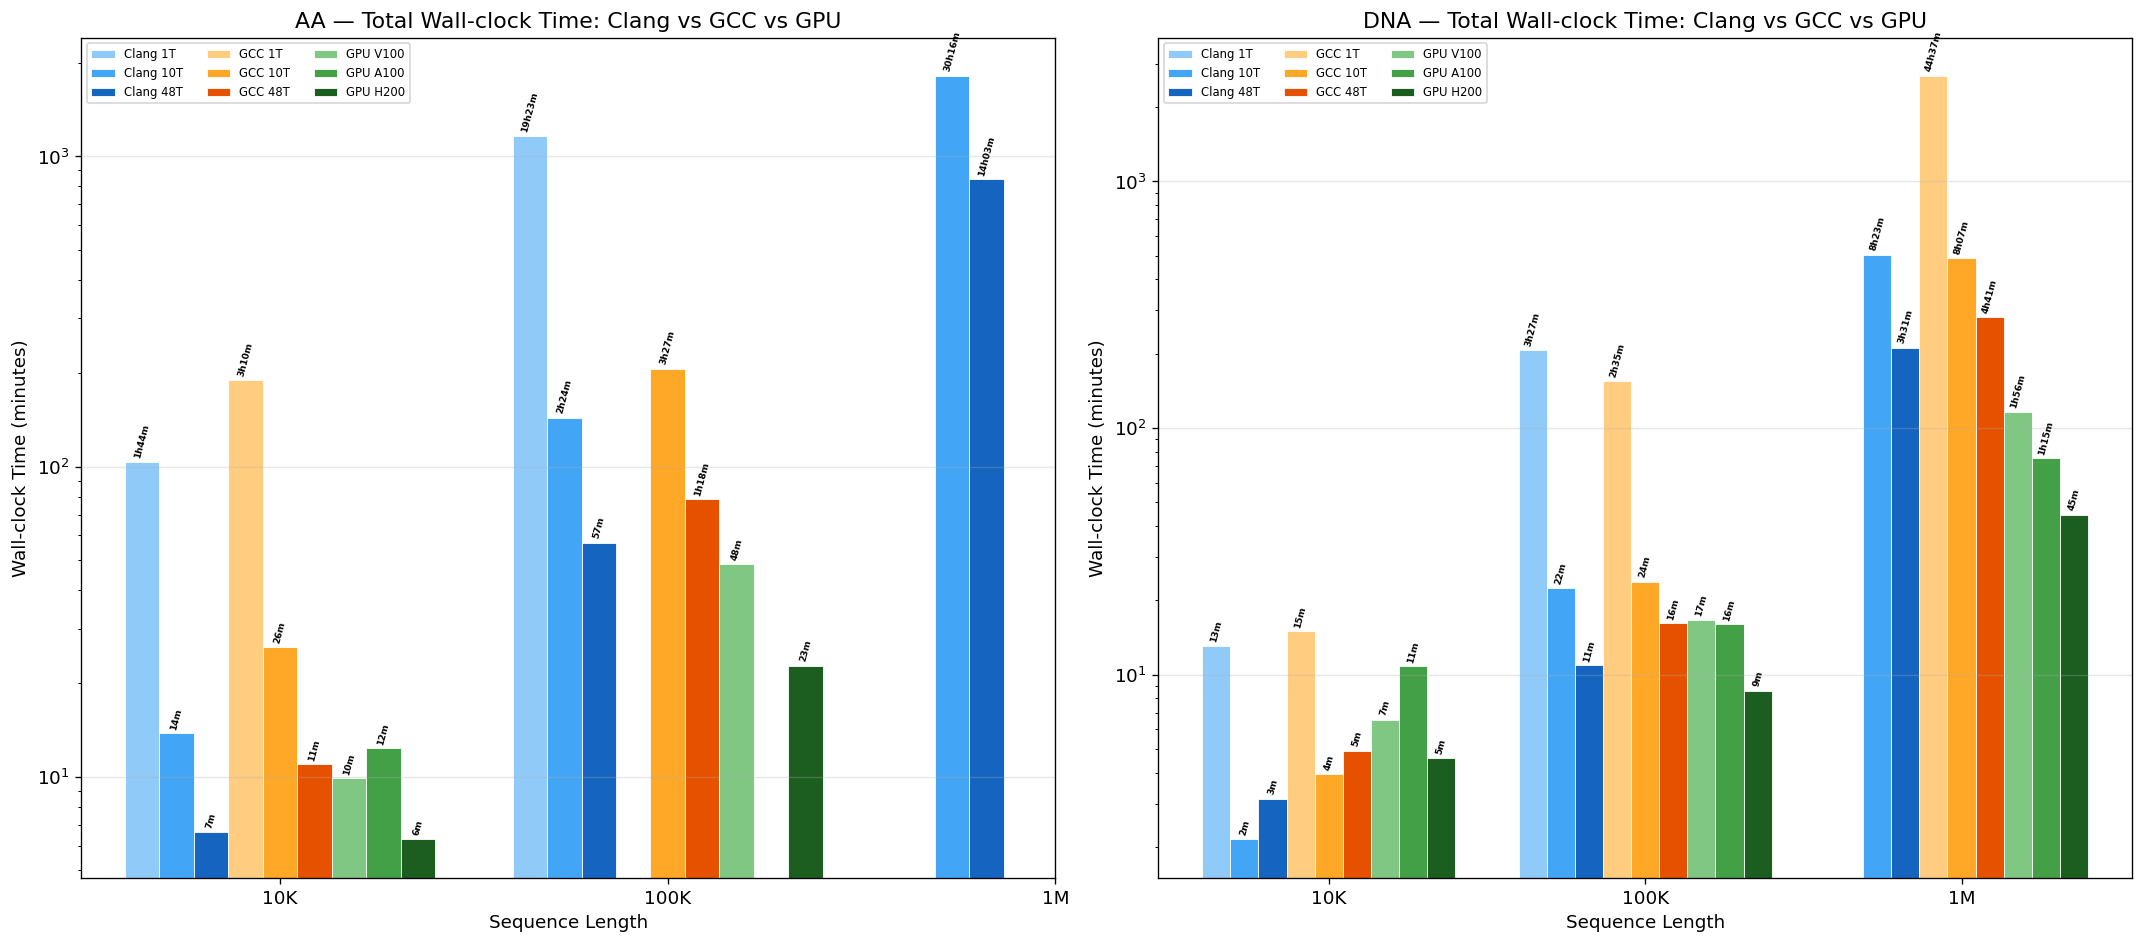

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for idx, dtype in enumerate(['AA', 'DNA']):
    ax = axes[idx]
    df_sub = df_combined[df_combined['data_type'] == dtype]
    
    lengths = sorted(df_sub['length'].unique())
    length_labels = [f'{l//1000}K' if l < 1000000 else '1M' for l in lengths]
    x = np.arange(len(lengths))
    
    n_configs = len(config_specs)
    width = 0.8 / n_configs
    
    for i, (label, compiler, exec_type, color) in enumerate(config_specs):
        vals = []
        for l in lengths:
            v = df_sub[(df_sub['compiler'] == compiler) & (df_sub['exec_type'] == exec_type) & (df_sub['length'] == l)]['wall_total_min']
            vals.append(v.values[0] if len(v) > 0 else 0)
        offset = (i - n_configs/2 + 0.5) * width
        plot_vals = [v if v > 0 else np.nan for v in vals]
        bars = ax.bar(x + offset, plot_vals, width,
                      label=label, color=color, edgecolor='white', linewidth=0.5)
        
        # Add time labels on top of bars
        for bar, v in zip(bars, vals):
            if v > 0:
                ax.annotate(fmt_time(v), xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                           xytext=(0, 2), textcoords='offset points',
                           ha='center', va='bottom', fontsize=5.5, rotation=75, fontweight='bold')
    
    ax.set_xlabel('Sequence Length')
    ax.set_ylabel('Wall-clock Time (minutes)')
    ax.set_title(f'{dtype} — Total Wall-clock Time: Clang vs GCC vs GPU')
    ax.set_xticks(x)
    ax.set_xticklabels(length_labels)
    ax.legend(fontsize=7, ncol=3, loc='upper left')
    ax.set_yscale('log')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('/Users/u7826985/Projects/Nvidia/poc-gpu-likelihood-calculation_analysis/2026_05_08_clang_outputs/fig01_walltime_clang_vs_gcc_vs_gpu.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# CSV for fig01: Total wall-clock time
out_dir = '/Users/u7826985/Projects/Nvidia/poc-gpu-likelihood-calculation_analysis/2026_05_08_clang_outputs'
rows = []
for _, (label, compiler, exec_type, _) in enumerate(config_specs):
    for dtype in ['AA', 'DNA']:
        df_sub = df_combined[(df_combined['data_type'] == dtype) & (df_combined['compiler'] == compiler) & (df_combined['exec_type'] == exec_type)]
        for _, r in df_sub.iterrows():
            rows.append({'Data Type': dtype, 'Config': label, 'Length': r['length_label'],
                         'Wall Total (sec)': round(r['wall_total_sec'], 1),
                         'Wall Total (min)': round(r['wall_total_min'], 1),
                         'Wall Total (hm)': fmt_time(r['wall_total_min']),
                         'Command': r.get('command', '')})
df_fig01 = pd.DataFrame(rows).sort_values(['Data Type', 'Length', 'Config'])
df_fig01.to_csv(os.path.join(out_dir, 'fig01_walltime_data.csv'), index=False)
print(f"Saved fig01_walltime_data.csv ({len(df_fig01)} rows)")
df_fig01

Saved fig01_walltime_data.csv (44 rows)


,Data Type,Config,Length,Wall Total (sec),Wall Total (min),Wall Total (hm),Command
5,AA,Clang 10T,100K,8611.1,143.5,2h24m,/scratch/dx61/sa0557/iqtree2/ci-cd-mem-auto/bu...
0,AA,Clang 1T,100K,69795.4,1163.3,19h23m,/scratch/dx61/sa0557/iqtree2/ci-cd-mem-auto/bu...
11,AA,Clang 48T,100K,3408.0,56.8,57m,/scratch/dx61/sa0557/iqtree2/ci-cd-mem-auto/bu...
21,AA,GCC 10T,100K,12406.6,206.8,3h27m,/scratch/dx61/sa0557/iqtree2/ci-cd-nonrev/buil...
26,AA,GCC 48T,100K,4704.7,78.4,1h18m,/scratch/dx61/sa0557/iqtree2/ci-cd-nonrev/buil...
40,AA,GPU H200,100K,1367.1,22.8,23m,/scratch/dx61/sa0557/iqtree2/ci-cd-mem-less/bu...
31,AA,GPU V100,100K,2905.5,48.4,48m,/scratch/dx61/sa0557/iqtree2/ci-cd-mem-less/bu...
6,AA,Clang 10T,10K,827.8,13.8,14m,/scratch/dx61/sa0557/iqtree2/ci-cd-mem-auto/bu...
1,AA,Clang 1T,10K,6217.5,103.6,1h44m,/scratch/dx61/sa0557/iqtree2/ci-cd-mem-auto/bu...
12,AA,Clang 48T,10K,397.9,6.6,7m,/scratch/dx61/sa0557/iqtree2/ci-cd-mem-auto/bu...


## 5. Speedup ratio: GCC / Clang (values > 1 mean Clang is faster)

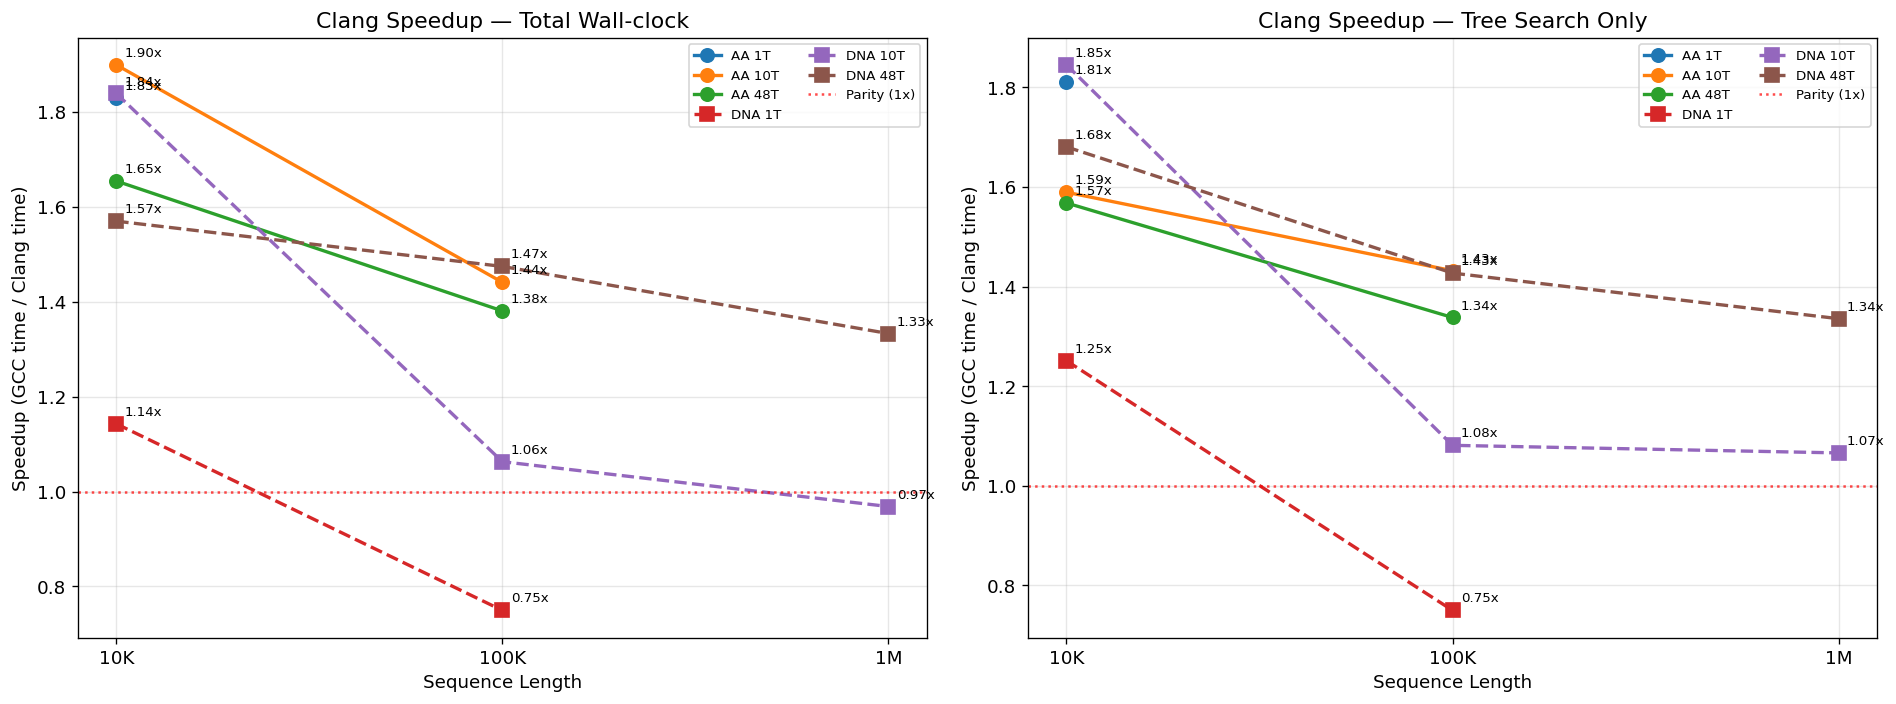


Speedup Summary (GCC_time / Clang_time — values > 1 mean Clang is faster):


,data_type,exec_type,length_label,speedup_total,speedup_treesearch,lnl_diff
1,AA,OMP_10,100K,1.440761,1.431842,-0.002
2,AA,OMP_10,10K,1.898826,1.589494,0.000
3,AA,OMP_48,100K,1.380494,1.337916,0.000
4,AA,OMP_48,10K,1.654092,1.567966,0.000
0,AA,VANILA,10K,1.829672,1.810560,0.000
7,DNA,OMP_10,1M,0.968399,1.065971,0.000
8,DNA,OMP_10,100K,1.062871,1.081185,0.000
9,DNA,OMP_10,10K,1.838565,1.845260,0.000
10,DNA,OMP_48,1M,1.332839,1.335524,0.000
11,DNA,OMP_48,100K,1.474231,1.427122,0.000


In [7]:
# Compute speedup: GCC_time / Clang_time (>1 means Clang is faster)
merge_keys = ['data_type', 'exec_type', 'length']
df_clang_m = df_combined[df_combined['compiler'] == 'Clang'][merge_keys + ['wall_total_sec', 'wall_treesearch_sec', 'best_lnl']].rename(
    columns={'wall_total_sec': 'clang_wall', 'wall_treesearch_sec': 'clang_treesearch', 'best_lnl': 'clang_lnl'})
df_gcc_m = df_combined[df_combined['compiler'] == 'GCC'][merge_keys + ['wall_total_sec', 'wall_treesearch_sec', 'best_lnl']].rename(
    columns={'wall_total_sec': 'gcc_wall', 'wall_treesearch_sec': 'gcc_treesearch', 'best_lnl': 'gcc_lnl'})

df_speedup = pd.merge(df_clang_m, df_gcc_m, on=merge_keys, how='inner')
df_speedup['speedup_total'] = df_speedup['gcc_wall'] / df_speedup['clang_wall']
df_speedup['speedup_treesearch'] = df_speedup['gcc_treesearch'] / df_speedup['clang_treesearch']
df_speedup['lnl_diff'] = df_speedup['clang_lnl'] - df_speedup['gcc_lnl']
df_speedup['length_label'] = df_speedup['length'].map({10000: '10K', 100000: '100K', 1000000: '1M'})

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, metric in enumerate(['speedup_total', 'speedup_treesearch']):
    ax = axes[idx]
    title = 'Total Wall-clock' if metric == 'speedup_total' else 'Tree Search Only'
    
    for dtype in ['AA', 'DNA']:
        df_sub = df_speedup[df_speedup['data_type'] == dtype]
        for et in ['VANILA', 'OMP_10', 'OMP_48']:
            d = df_sub[df_sub['exec_type'] == et].sort_values('length')
            if len(d) == 0:
                continue
            marker = 'o' if dtype == 'AA' else 's'
            ls = '-' if dtype == 'AA' else '--'
            thread_label = {'VANILA': '1T', 'OMP_10': '10T', 'OMP_48': '48T'}[et]
            ax.plot(d['length_label'].values, d[metric].values, marker=marker, linestyle=ls,
                    label=f'{dtype} {thread_label}', markersize=8, linewidth=2)
            # Annotate values
            for i_row, (_, row) in enumerate(d.iterrows()):
                ax.annotate(f'{row[metric]:.2f}x', (i_row, row[metric]),
                           textcoords='offset points', xytext=(5, 5), fontsize=8)
    
    ax.axhline(y=1.0, color='red', linestyle=':', linewidth=1.5, alpha=0.7, label='Parity (1x)')
    ax.set_xlabel('Sequence Length')
    ax.set_ylabel('Speedup (GCC time / Clang time)')
    ax.set_title(f'Clang Speedup — {title}')
    ax.legend(fontsize=8, ncol=2)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/Users/u7826985/Projects/Nvidia/poc-gpu-likelihood-calculation_analysis/2026_05_08_clang_outputs/fig02_speedup_clang_vs_gcc.png', dpi=150, bbox_inches='tight')
plt.show()

# Print speedup table
print("\nSpeedup Summary (GCC_time / Clang_time — values > 1 mean Clang is faster):")
df_speedup[['data_type', 'exec_type', 'length_label', 'speedup_total', 'speedup_treesearch', 'lnl_diff']].sort_values(['data_type', 'exec_type'])

In [8]:
# CSV for fig02: Clang vs GCC speedup
df_fig02 = df_speedup[['data_type', 'exec_type', 'length_label',
                        'clang_wall', 'gcc_wall', 'speedup_total',
                        'clang_treesearch', 'gcc_treesearch', 'speedup_treesearch',
                        'lnl_diff']].copy()
df_fig02.columns = ['Data Type', 'Exec Type', 'Length',
                     'Clang Wall (s)', 'GCC Wall (s)', 'Total Speedup',
                     'Clang TreeSearch (s)', 'GCC TreeSearch (s)', 'TreeSearch Speedup',
                     'LnL Diff']
df_fig02 = df_fig02.sort_values(['Data Type', 'Exec Type'])
df_fig02.to_csv(os.path.join(out_dir, 'fig02_speedup_clang_vs_gcc.csv'), index=False)
print(f"Saved fig02_speedup_clang_vs_gcc.csv ({len(df_fig02)} rows)")
df_fig02

Saved fig02_speedup_clang_vs_gcc.csv (13 rows)


,Data Type,Exec Type,Length,Clang Wall (s),GCC Wall (s),Total Speedup,Clang TreeSearch (s),GCC TreeSearch (s),TreeSearch Speedup,LnL Diff
1,AA,OMP_10,100K,8611.117,12406.564,1.440761,5497.912,7872.139,1.431842,-0.002
2,AA,OMP_10,10K,827.765,1571.782,1.898826,485.630,771.906,1.589494,0.000
3,AA,OMP_48,100K,3407.967,4704.677,1.380494,2471.316,3306.413,1.337916,0.000
4,AA,OMP_48,10K,397.886,658.140,1.654092,269.703,422.885,1.567966,0.000
0,AA,VANILA,10K,6217.484,11375.955,1.829672,3494.261,6326.570,1.810560,0.000
7,DNA,OMP_10,1M,30204.307,29249.823,0.968399,12629.311,13462.480,1.065971,0.000
8,DNA,OMP_10,100K,1344.825,1429.376,1.062871,886.545,958.519,1.081185,0.000
9,DNA,OMP_10,10K,128.683,236.592,1.838565,88.846,163.944,1.845260,0.000
10,DNA,OMP_48,1M,12660.557,16874.486,1.332839,6630.427,8855.097,1.335524,0.000
11,DNA,OMP_48,100K,656.138,967.299,1.474231,521.357,744.040,1.427122,0.000


## 6. Tree search wall-time comparison: Clang vs GCC vs GPU

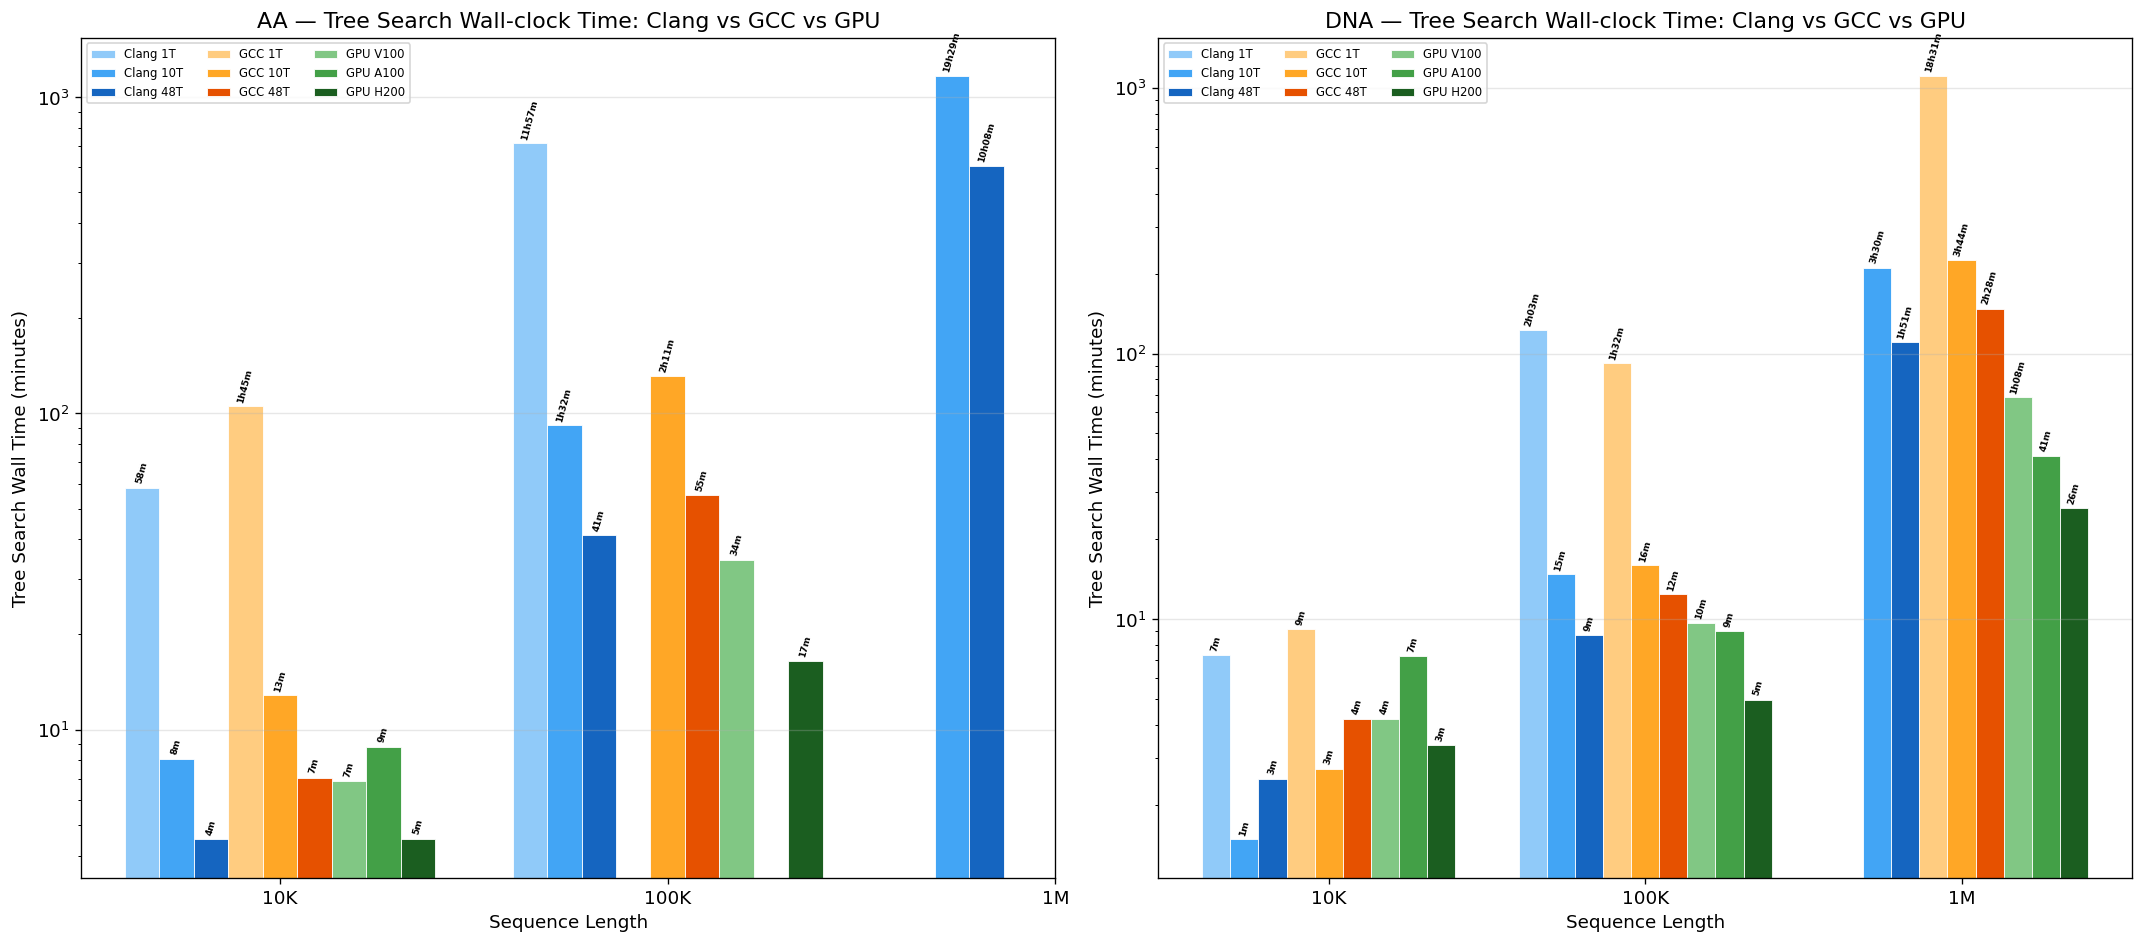

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for idx, dtype in enumerate(['AA', 'DNA']):
    ax = axes[idx]
    df_sub = df_combined[df_combined['data_type'] == dtype]
    
    lengths = sorted(df_sub['length'].unique())
    length_labels = [f'{l//1000}K' if l < 1000000 else '1M' for l in lengths]
    x = np.arange(len(lengths))
    
    n_configs = len(config_specs)
    width = 0.8 / n_configs
    
    for i, (label, compiler, exec_type, color) in enumerate(config_specs):
        vals = []
        for l in lengths:
            v = df_sub[(df_sub['compiler'] == compiler) & (df_sub['exec_type'] == exec_type) & (df_sub['length'] == l)]['wall_treesearch_min']
            vals.append(v.values[0] if len(v) > 0 else 0)
        offset = (i - n_configs/2 + 0.5) * width
        plot_vals = [v if v > 0 else np.nan for v in vals]
        bars = ax.bar(x + offset, plot_vals, width,
               label=label, color=color, edgecolor='white', linewidth=0.5)
        
        # Add time labels on top of bars
        for bar, v in zip(bars, vals):
            if v > 0:
                ax.annotate(fmt_time(v), xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                           xytext=(0, 2), textcoords='offset points',
                           ha='center', va='bottom', fontsize=5.5, rotation=75, fontweight='bold')
    
    ax.set_xlabel('Sequence Length')
    ax.set_ylabel('Tree Search Wall Time (minutes)')
    ax.set_title(f'{dtype} — Tree Search Wall-clock Time: Clang vs GCC vs GPU')
    ax.set_xticks(x)
    ax.set_xticklabels(length_labels)
    ax.legend(fontsize=7, ncol=3, loc='upper left')
    ax.set_yscale('log')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('/Users/u7826985/Projects/Nvidia/poc-gpu-likelihood-calculation_analysis/2026_05_08_clang_outputs/fig03_treesearch_walltime.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# CSV for fig03: Tree search wall-clock time
rows = []
for _, (label, compiler, exec_type, _) in enumerate(config_specs):
    for dtype in ['AA', 'DNA']:
        df_sub = df_combined[(df_combined['data_type'] == dtype) & (df_combined['compiler'] == compiler) & (df_combined['exec_type'] == exec_type)]
        for _, r in df_sub.iterrows():
            rows.append({'Data Type': dtype, 'Config': label, 'Length': r['length_label'],
                         'TreeSearch (sec)': round(r['wall_treesearch_sec'], 1) if pd.notna(r['wall_treesearch_sec']) else None,
                         'TreeSearch (min)': round(r['wall_treesearch_min'], 1) if pd.notna(r['wall_treesearch_min']) else None,
                         'TreeSearch (hm)': fmt_time(r['wall_treesearch_min']) if pd.notna(r['wall_treesearch_min']) else None,
                         'Command': r.get('command', '')})
df_fig03 = pd.DataFrame(rows).sort_values(['Data Type', 'Length', 'Config'])
df_fig03.to_csv(os.path.join(out_dir, 'fig03_treesearch_data.csv'), index=False)
print(f"Saved fig03_treesearch_data.csv ({len(df_fig03)} rows)")
df_fig03

Saved fig03_treesearch_data.csv (44 rows)


,Data Type,Config,Length,TreeSearch (sec),TreeSearch (min),TreeSearch (hm),Command
5,AA,Clang 10T,100K,5497.9,91.6,1h32m,/scratch/dx61/sa0557/iqtree2/ci-cd-mem-auto/bu...
0,AA,Clang 1T,100K,42993.6,716.6,11h57m,/scratch/dx61/sa0557/iqtree2/ci-cd-mem-auto/bu...
11,AA,Clang 48T,100K,2471.3,41.2,41m,/scratch/dx61/sa0557/iqtree2/ci-cd-mem-auto/bu...
21,AA,GCC 10T,100K,7872.1,131.2,2h11m,/scratch/dx61/sa0557/iqtree2/ci-cd-nonrev/buil...
26,AA,GCC 48T,100K,3306.4,55.1,55m,/scratch/dx61/sa0557/iqtree2/ci-cd-nonrev/buil...
40,AA,GPU H200,100K,991.1,16.5,17m,/scratch/dx61/sa0557/iqtree2/ci-cd-mem-less/bu...
31,AA,GPU V100,100K,2065.6,34.4,34m,/scratch/dx61/sa0557/iqtree2/ci-cd-mem-less/bu...
6,AA,Clang 10T,10K,485.6,8.1,8m,/scratch/dx61/sa0557/iqtree2/ci-cd-mem-auto/bu...
1,AA,Clang 1T,10K,3494.3,58.2,58m,/scratch/dx61/sa0557/iqtree2/ci-cd-mem-auto/bu...
12,AA,Clang 48T,10K,269.7,4.5,4m,/scratch/dx61/sa0557/iqtree2/ci-cd-mem-auto/bu...


## 7. Log-likelihood comparison (correctness check)

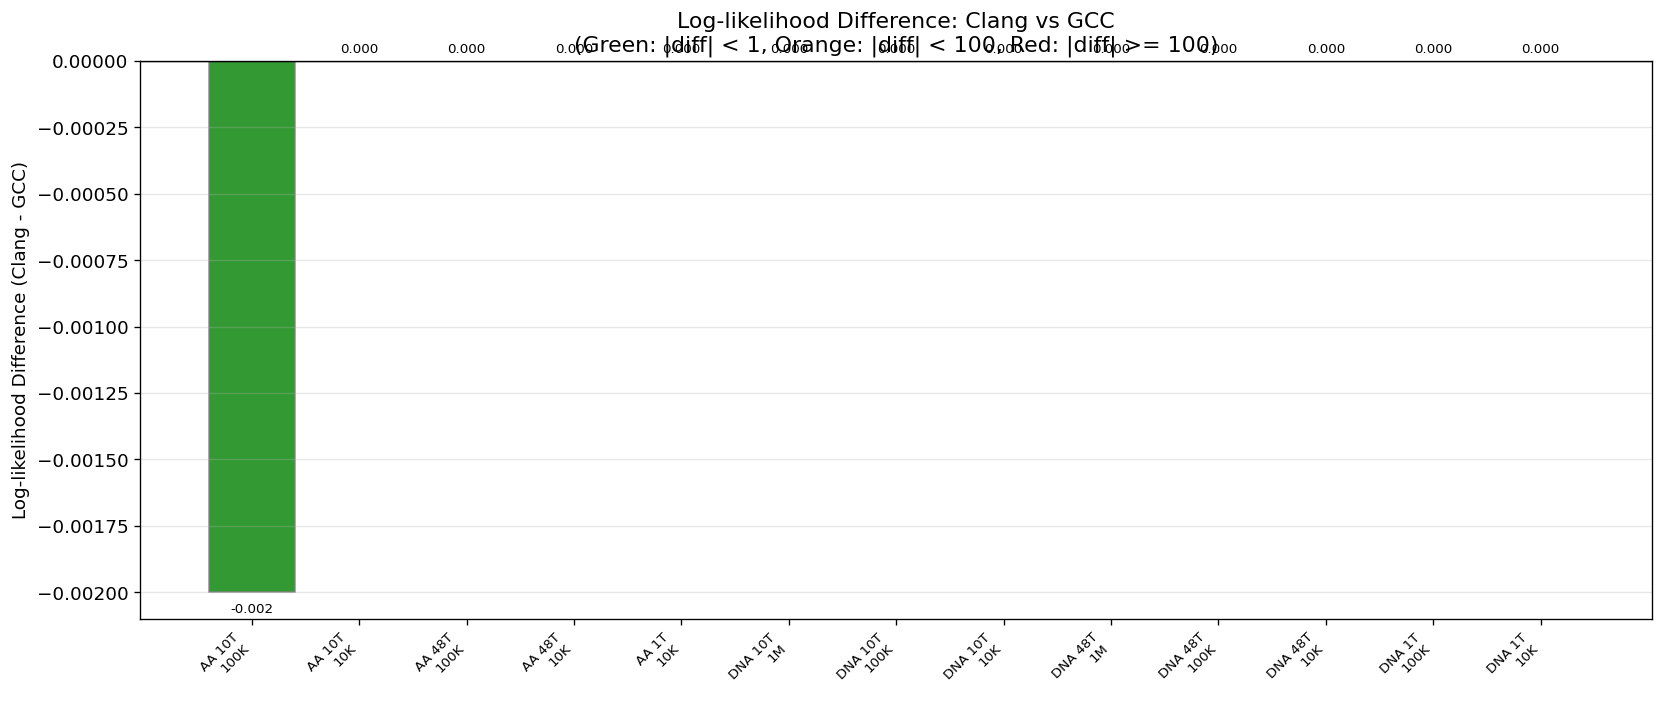


Log-likelihood values:


,data_type,exec_type,length_label,clang_lnl,gcc_lnl,lnl_diff
1,AA,OMP_10,100K,-7.541977e+06,-7.541977e+06,-0.002
2,AA,OMP_10,10K,-8.073500e+05,-8.073500e+05,0.000
3,AA,OMP_48,100K,-7.541977e+06,-7.541977e+06,0.000
4,AA,OMP_48,10K,-8.073500e+05,-8.073500e+05,0.000
0,AA,VANILA,10K,-8.073500e+05,-8.073500e+05,0.000
7,DNA,OMP_10,1M,-5.920802e+07,-5.920802e+07,0.000
8,DNA,OMP_10,100K,-5.692985e+06,-5.692985e+06,0.000
9,DNA,OMP_10,10K,-5.642088e+05,-5.642088e+05,0.000
10,DNA,OMP_48,1M,-5.920802e+07,-5.920802e+07,0.000
11,DNA,OMP_48,100K,-5.692985e+06,-5.692985e+06,0.000


In [11]:
fig, ax = plt.subplots(1, 1, figsize=(14, 6))

df_lnl = df_speedup.copy()
df_lnl['label'] = df_lnl['data_type'] + ' ' + df_lnl['exec_type'].map({'VANILA': '1T', 'OMP_10': '10T', 'OMP_48': '48T'}) + '\n' + df_lnl['length_label']
df_lnl = df_lnl.sort_values(['data_type', 'exec_type'])

colors = ['green' if abs(d) < 1 else 'orange' if abs(d) < 100 else 'red' for d in df_lnl['lnl_diff']]
bars = ax.bar(range(len(df_lnl)), df_lnl['lnl_diff'], color=colors, edgecolor='gray', alpha=0.8)

for i, (_, row) in enumerate(df_lnl.iterrows()):
    ax.annotate(f'{row["lnl_diff"]:.3f}', (i, row['lnl_diff']),
               textcoords='offset points', xytext=(0, 5 if row['lnl_diff'] >= 0 else -12),
               ha='center', fontsize=8)

ax.set_xticks(range(len(df_lnl)))
ax.set_xticklabels(df_lnl['label'], fontsize=8, rotation=45, ha='right')
ax.axhline(y=0, color='black', linewidth=0.8)
ax.set_ylabel('Log-likelihood Difference (Clang - GCC)')
ax.set_title('Log-likelihood Difference: Clang vs GCC\n(Green: |diff| < 1, Orange: |diff| < 100, Red: |diff| >= 100)')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('/Users/u7826985/Projects/Nvidia/poc-gpu-likelihood-calculation_analysis/2026_05_08_clang_outputs/fig04_lnl_diff.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nLog-likelihood values:")
df_lnl[['data_type', 'exec_type', 'length_label', 'clang_lnl', 'gcc_lnl', 'lnl_diff']]

In [12]:
# CSV for fig04: Log-likelihood differences
df_fig04 = df_lnl[['data_type', 'exec_type', 'length_label', 'clang_lnl', 'gcc_lnl', 'lnl_diff']].copy()
df_fig04.columns = ['Data Type', 'Exec Type', 'Length', 'Clang LnL', 'GCC LnL', 'LnL Diff']
df_fig04.to_csv(os.path.join(out_dir, 'fig04_lnl_diff.csv'), index=False)
print(f"Saved fig04_lnl_diff.csv ({len(df_fig04)} rows)")
df_fig04

Saved fig04_lnl_diff.csv (13 rows)


,Data Type,Exec Type,Length,Clang LnL,GCC LnL,LnL Diff
1,AA,OMP_10,100K,-7.541977e+06,-7.541977e+06,-0.002
2,AA,OMP_10,10K,-8.073500e+05,-8.073500e+05,0.000
3,AA,OMP_48,100K,-7.541977e+06,-7.541977e+06,0.000
4,AA,OMP_48,10K,-8.073500e+05,-8.073500e+05,0.000
0,AA,VANILA,10K,-8.073500e+05,-8.073500e+05,0.000
7,DNA,OMP_10,1M,-5.920802e+07,-5.920802e+07,0.000
8,DNA,OMP_10,100K,-5.692985e+06,-5.692985e+06,0.000
9,DNA,OMP_10,10K,-5.642088e+05,-5.642088e+05,0.000
10,DNA,OMP_48,1M,-5.920802e+07,-5.920802e+07,0.000
11,DNA,OMP_48,100K,-5.692985e+06,-5.692985e+06,0.000


## 8. Speedup vs GCC 1-thread baseline: all configurations including GPU

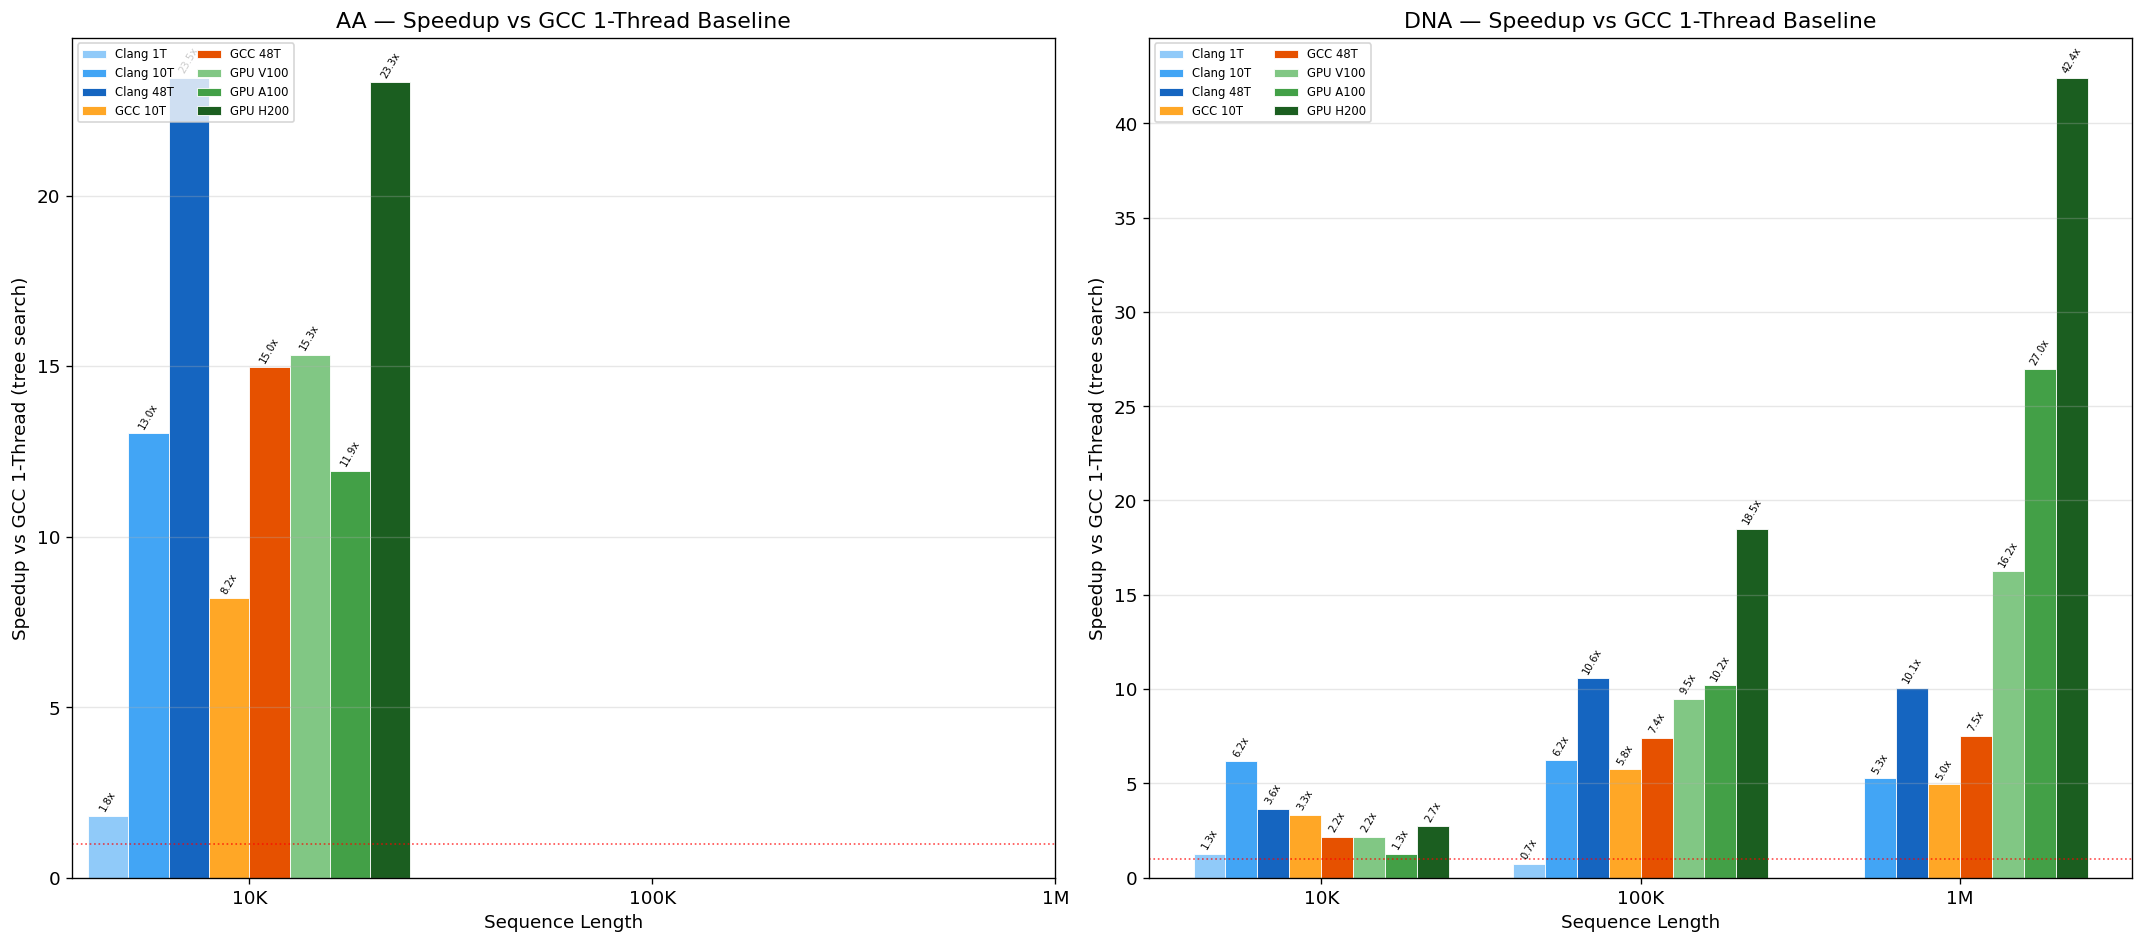

In [13]:
# Compute speedup of every config vs GCC 1-thread (VANILA) baseline
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for idx, dtype in enumerate(['AA', 'DNA']):
    ax = axes[idx]
    df_sub = df_combined[df_combined['data_type'] == dtype]
    
    lengths = sorted(df_sub['length'].unique())
    length_labels = [f'{l//1000}K' if l < 1000000 else '1M' for l in lengths]
    
    # Get GCC 1T baseline for each length
    baselines = {}
    for l in lengths:
        b = df_sub[(df_sub['compiler'] == 'GCC') & (df_sub['exec_type'] == 'VANILA') & (df_sub['length'] == l)]['wall_treesearch_sec']
        baselines[l] = b.values[0] if len(b) > 0 else None
    
    # Skip configs that are the baseline itself
    plot_configs = [c for c in config_specs if not (c[1] == 'GCC' and c[2] == 'VANILA')]
    
    x = np.arange(len(lengths))
    n = len(plot_configs)
    width = 0.8 / n
    
    for i, (label, compiler, exec_type, color) in enumerate(plot_configs):
        speedups = []
        for l in lengths:
            v = df_sub[(df_sub['compiler'] == compiler) & (df_sub['exec_type'] == exec_type) & (df_sub['length'] == l)]['wall_treesearch_sec']
            if len(v) > 0 and baselines.get(l):
                speedups.append(baselines[l] / v.values[0])
            else:
                speedups.append(np.nan)
        
        offset = (i - n/2 + 0.5) * width
        bars = ax.bar(x + offset, speedups, width, label=label, color=color, edgecolor='white', linewidth=0.5)
        
        # Annotate
        for j, s in enumerate(speedups):
            if not np.isnan(s):
                ax.annotate(f'{s:.1f}x', (x[j] + offset, s), textcoords='offset points',
                           xytext=(0, 3), ha='center', fontsize=6, rotation=60)
    
    ax.axhline(y=1.0, color='red', linestyle=':', linewidth=1, alpha=0.7)
    ax.set_xlabel('Sequence Length')
    ax.set_ylabel('Speedup vs GCC 1-Thread (tree search)')
    ax.set_title(f'{dtype} — Speedup vs GCC 1-Thread Baseline')
    ax.set_xticks(x)
    ax.set_xticklabels(length_labels)
    ax.legend(fontsize=7, ncol=2, loc='upper left')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('/Users/u7826985/Projects/Nvidia/poc-gpu-likelihood-calculation_analysis/2026_05_08_clang_outputs/fig05_speedup_vs_gcc1t_baseline.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# CSV for fig05 & fig06: Speedup vs GCC 1T baseline for all configs
rows = []
for dtype in ['AA', 'DNA']:
    df_sub = df_combined[df_combined['data_type'] == dtype]
    lengths = sorted(df_sub['length'].unique())
    baselines = {}
    for l in lengths:
        b = df_sub[(df_sub['compiler'] == 'GCC') & (df_sub['exec_type'] == 'VANILA') & (df_sub['length'] == l)]['wall_treesearch_sec']
        baselines[l] = b.values[0] if len(b) > 0 else None
    for label, compiler, exec_type, _ in config_specs:
        for l in lengths:
            v = df_sub[(df_sub['compiler'] == compiler) & (df_sub['exec_type'] == exec_type) & (df_sub['length'] == l)]['wall_treesearch_sec']
            ll = {10000: '10K', 100000: '100K', 1000000: '1M'}[l]
            if len(v) > 0 and baselines.get(l):
                rows.append({'Data Type': dtype, 'Config': label, 'Length': ll,
                             'TreeSearch (sec)': round(v.values[0], 1),
                             'GCC 1T Baseline (sec)': round(baselines[l], 1),
                             'Speedup vs GCC 1T': round(baselines[l] / v.values[0], 2)})
            else:
                rows.append({'Data Type': dtype, 'Config': label, 'Length': ll,
                             'TreeSearch (sec)': round(v.values[0], 1) if len(v) > 0 else None,
                             'GCC 1T Baseline (sec)': round(baselines[l], 1) if baselines.get(l) else None,
                             'Speedup vs GCC 1T': None})
df_fig05 = pd.DataFrame(rows).sort_values(['Data Type', 'Length', 'Config'])
df_fig05.to_csv(os.path.join(out_dir, 'fig05_fig06_speedup_vs_gcc1t.csv'), index=False)
print(f"Saved fig05_fig06_speedup_vs_gcc1t.csv ({len(df_fig05)} rows)")
df_fig05

Saved fig05_fig06_speedup_vs_gcc1t.csv (54 rows)


,Data Type,Config,Length,TreeSearch (sec),GCC 1T Baseline (sec),Speedup vs GCC 1T
4,AA,Clang 10T,100K,5497.9,NaN,NaN
1,AA,Clang 1T,100K,42993.6,NaN,NaN
7,AA,Clang 48T,100K,2471.3,NaN,NaN
13,AA,GCC 10T,100K,7872.1,NaN,NaN
10,AA,GCC 1T,100K,NaN,NaN,NaN
16,AA,GCC 48T,100K,3306.4,NaN,NaN
22,AA,GPU A100,100K,NaN,NaN,NaN
25,AA,GPU H200,100K,991.1,NaN,NaN
19,AA,GPU V100,100K,2065.6,NaN,NaN
3,AA,Clang 10T,10K,485.6,6326.6,13.03


## 9. Speedup heatmap: all configs vs GCC 1-Thread baseline

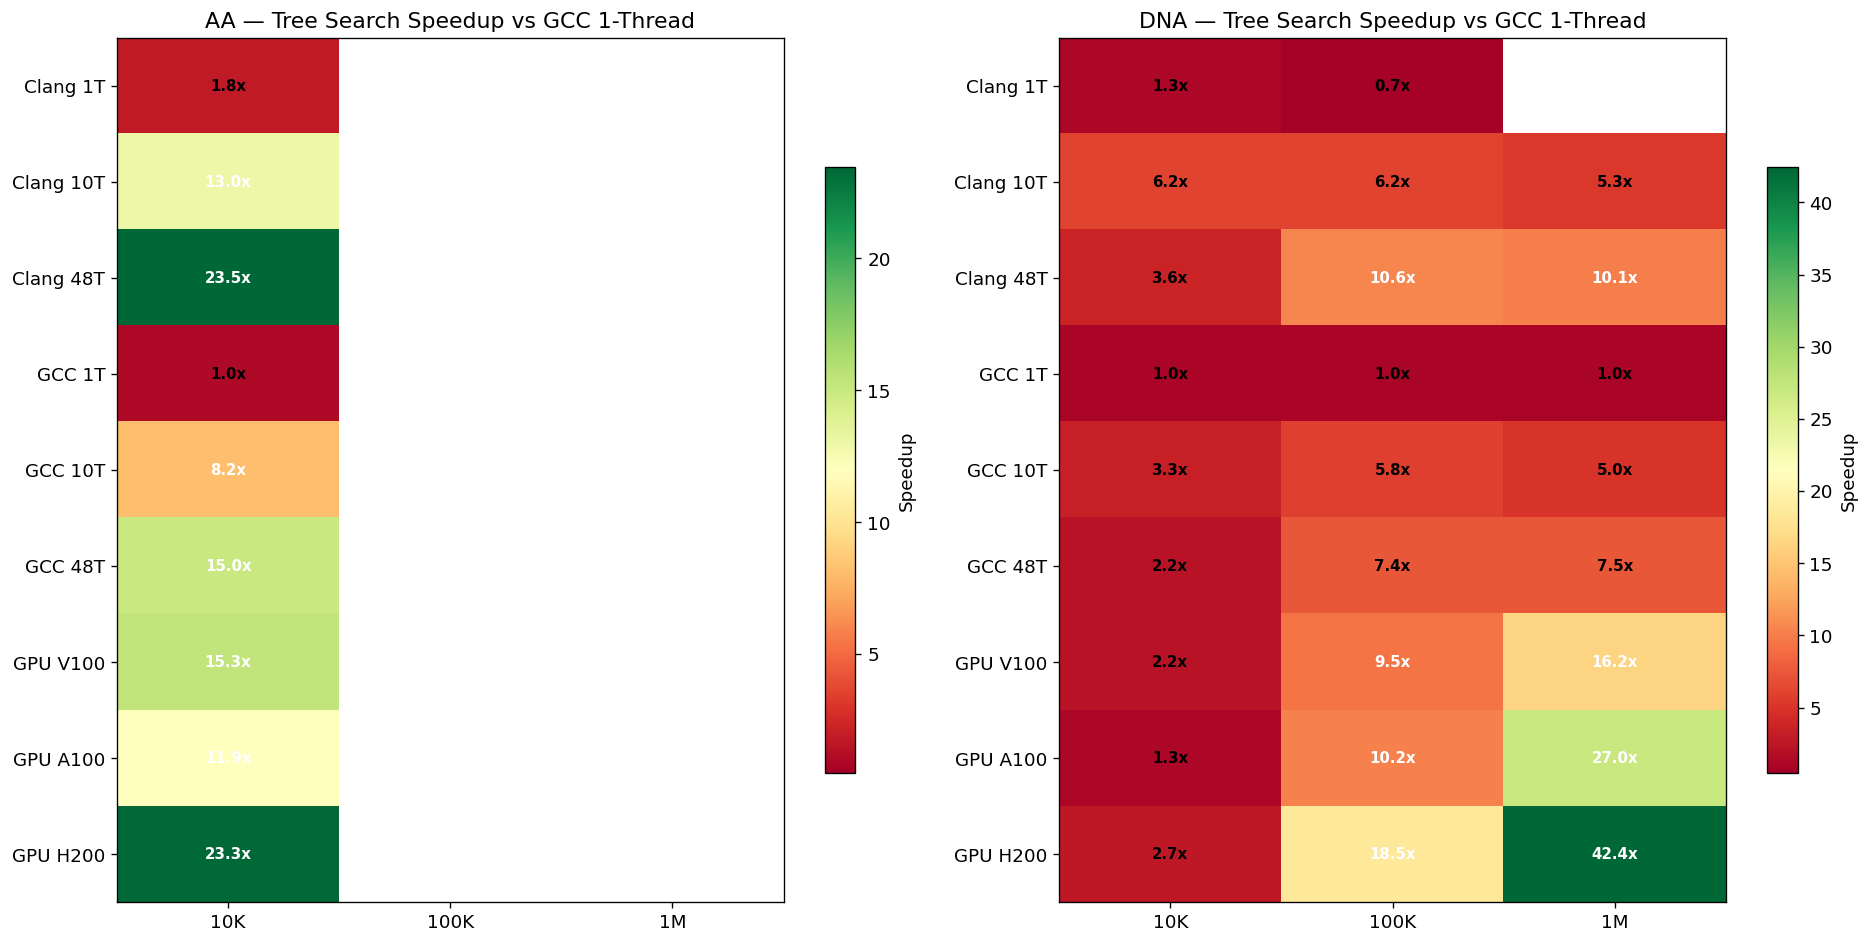

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for idx, dtype in enumerate(['AA', 'DNA']):
    ax = axes[idx]
    df_sub = df_combined[df_combined['data_type'] == dtype]
    
    lengths = sorted(df_sub['length'].unique())
    length_labels = [f'{l//1000}K' if l < 1000000 else '1M' for l in lengths]
    
    # GCC 1T baseline
    baselines = {}
    for l in lengths:
        b = df_sub[(df_sub['compiler'] == 'GCC') & (df_sub['exec_type'] == 'VANILA') & (df_sub['length'] == l)]['wall_treesearch_sec']
        baselines[l] = b.values[0] if len(b) > 0 else None
    
    # All configs except GCC 1T baseline
    all_configs = config_specs  # include GCC 1T too for reference
    
    rows = []
    row_labels = []
    for label, compiler, exec_type, _ in all_configs:
        row = []
        for l in lengths:
            v = df_sub[(df_sub['compiler'] == compiler) & (df_sub['exec_type'] == exec_type) & (df_sub['length'] == l)]['wall_treesearch_sec']
            if len(v) > 0 and baselines.get(l):
                row.append(baselines[l] / v.values[0])
            else:
                row.append(np.nan)
        rows.append(row)
        row_labels.append(label)
    
    data = np.array(rows)
    
    im = ax.imshow(data, cmap='RdYlGn', aspect='auto', vmin=0.5, vmax=max(np.nanmax(data), 10))
    
    ax.set_xticks(range(len(length_labels)))
    ax.set_xticklabels(length_labels)
    ax.set_yticks(range(len(row_labels)))
    ax.set_yticklabels(row_labels)
    
    for i in range(len(row_labels)):
        for j in range(len(length_labels)):
            val = data[i, j]
            if not np.isnan(val):
                color = 'white' if val > 8 or val < 0.7 else 'black'
                ax.text(j, i, f'{val:.1f}x', ha='center', va='center', fontsize=9, fontweight='bold', color=color)
    
    ax.set_title(f'{dtype} — Tree Search Speedup vs GCC 1-Thread')
    plt.colorbar(im, ax=ax, label='Speedup', shrink=0.7)

plt.tight_layout()
plt.savefig('/Users/u7826985/Projects/Nvidia/poc-gpu-likelihood-calculation_analysis/2026_05_08_clang_outputs/fig06_speedup_heatmap_all.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. GPU speedup over best CPU config (Clang 48T)

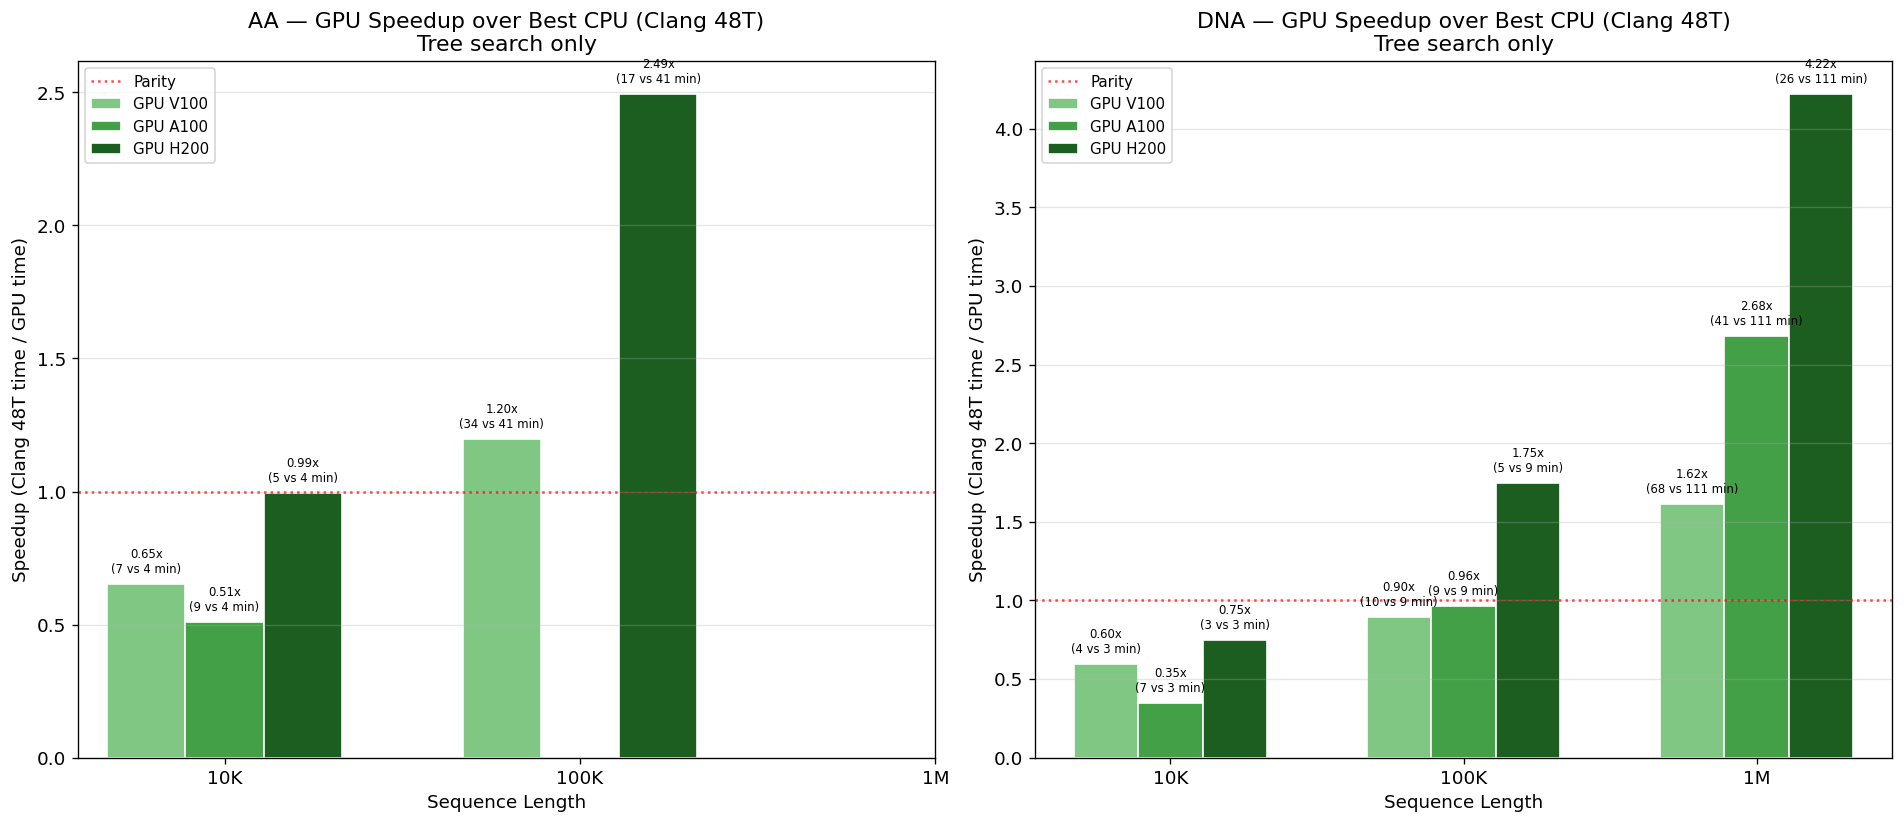

In [16]:
# Compare GPU vs best CPU (Clang 48T) for tree search time
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

gpu_colors = {'V100': '#81C784', 'A100': '#43A047', 'H200': '#1B5E20'}

for idx, dtype in enumerate(['AA', 'DNA']):
    ax = axes[idx]
    df_sub = df_combined[df_combined['data_type'] == dtype]
    
    lengths = sorted(df_sub['length'].unique())
    length_labels = [f'{l//1000}K' if l < 1000000 else '1M' for l in lengths]
    
    # Best CPU baseline: Clang 48T
    best_cpu = {}
    for l in lengths:
        v = df_sub[(df_sub['compiler'] == 'Clang') & (df_sub['exec_type'] == 'OMP_48') & (df_sub['length'] == l)]['wall_treesearch_sec']
        if len(v) > 0:
            best_cpu[l] = v.values[0]
        else:
            # fallback to GCC 48T
            v2 = df_sub[(df_sub['compiler'] == 'GCC') & (df_sub['exec_type'] == 'OMP_48') & (df_sub['length'] == l)]['wall_treesearch_sec']
            best_cpu[l] = v2.values[0] if len(v2) > 0 else None
    
    x = np.arange(len(lengths))
    width = 0.22
    
    for i, gpu_name in enumerate(['V100', 'A100', 'H200']):
        speedups = []
        gpu_times = []
        cpu_times = []
        for l in lengths:
            gv = df_sub[(df_sub['exec_type'] == f'GPU_{gpu_name}') & (df_sub['length'] == l)]['wall_treesearch_sec']
            if len(gv) > 0 and best_cpu.get(l):
                speedups.append(best_cpu[l] / gv.values[0])
                gpu_times.append(gv.values[0] / 60)
                cpu_times.append(best_cpu[l] / 60)
            else:
                speedups.append(np.nan)
                gpu_times.append(np.nan)
                cpu_times.append(np.nan)
        
        bars = ax.bar(x + (i-1)*width, speedups, width, label=f'GPU {gpu_name}',
                      color=gpu_colors[gpu_name], edgecolor='white')
        
        for j, (s, gt, ct) in enumerate(zip(speedups, gpu_times, cpu_times)):
            if not np.isnan(s):
                label_text = f'{s:.2f}x\n({gt:.0f} vs {ct:.0f} min)'
                ax.annotate(label_text, (x[j] + (i-1)*width, s),
                           textcoords='offset points', xytext=(0, 5),
                           ha='center', fontsize=7, va='bottom')
    
    ax.axhline(y=1.0, color='red', linestyle=':', linewidth=1.5, alpha=0.7, label='Parity')
    ax.set_xlabel('Sequence Length')
    ax.set_ylabel('Speedup (Clang 48T time / GPU time)')
    ax.set_title(f'{dtype} — GPU Speedup over Best CPU (Clang 48T)\nTree search only')
    ax.set_xticks(x)
    ax.set_xticklabels(length_labels)
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('/Users/u7826985/Projects/Nvidia/poc-gpu-likelihood-calculation_analysis/2026_05_08_clang_outputs/fig08_gpu_vs_best_cpu.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
# CSV for fig08: GPU speedup over best CPU (Clang 48T)
rows = []
for dtype in ['AA', 'DNA']:
    df_sub = df_combined[df_combined['data_type'] == dtype]
    lengths = sorted(df_sub['length'].unique())
    best_cpu = {}
    for l in lengths:
        v = df_sub[(df_sub['compiler'] == 'Clang') & (df_sub['exec_type'] == 'OMP_48') & (df_sub['length'] == l)]['wall_treesearch_sec']
        if len(v) > 0:
            best_cpu[l] = v.values[0]
        else:
            v2 = df_sub[(df_sub['compiler'] == 'GCC') & (df_sub['exec_type'] == 'OMP_48') & (df_sub['length'] == l)]['wall_treesearch_sec']
            best_cpu[l] = v2.values[0] if len(v2) > 0 else None
    for gpu_name in ['V100', 'A100', 'H200']:
        for l in lengths:
            ll = {10000: '10K', 100000: '100K', 1000000: '1M'}[l]
            gv = df_sub[(df_sub['exec_type'] == f'GPU_{gpu_name}') & (df_sub['length'] == l)]['wall_treesearch_sec']
            if len(gv) > 0 and best_cpu.get(l):
                rows.append({'Data Type': dtype, 'GPU': gpu_name, 'Length': ll,
                             'GPU TreeSearch (sec)': round(gv.values[0], 1),
                             'Clang 48T TreeSearch (sec)': round(best_cpu[l], 1),
                             'GPU Speedup vs Clang 48T': round(best_cpu[l] / gv.values[0], 2)})
            else:
                rows.append({'Data Type': dtype, 'GPU': gpu_name, 'Length': ll,
                             'GPU TreeSearch (sec)': round(gv.values[0], 1) if len(gv) > 0 else None,
                             'Clang 48T TreeSearch (sec)': round(best_cpu[l], 1) if best_cpu.get(l) else None,
                             'GPU Speedup vs Clang 48T': None})
df_fig08 = pd.DataFrame(rows).sort_values(['Data Type', 'Length', 'GPU'])
df_fig08.to_csv(os.path.join(out_dir, 'fig08_gpu_vs_best_cpu.csv'), index=False)
print(f"Saved fig08_gpu_vs_best_cpu.csv ({len(df_fig08)} rows)")
df_fig08

Saved fig08_gpu_vs_best_cpu.csv (18 rows)


,Data Type,GPU,Length,GPU TreeSearch (sec),Clang 48T TreeSearch (sec),GPU Speedup vs Clang 48T
4,AA,A100,100K,NaN,2471.3,NaN
7,AA,H200,100K,991.1,2471.3,2.49
1,AA,V100,100K,2065.6,2471.3,1.20
3,AA,A100,10K,530.7,269.7,0.51
6,AA,H200,10K,271.3,269.7,0.99
0,AA,V100,10K,412.6,269.7,0.65
5,AA,A100,1M,NaN,36484.7,NaN
8,AA,H200,1M,NaN,36484.7,NaN
2,AA,V100,1M,NaN,36484.7,NaN
13,DNA,A100,100K,540.3,521.4,0.96


## 11. OMP scaling efficiency: Clang vs GCC

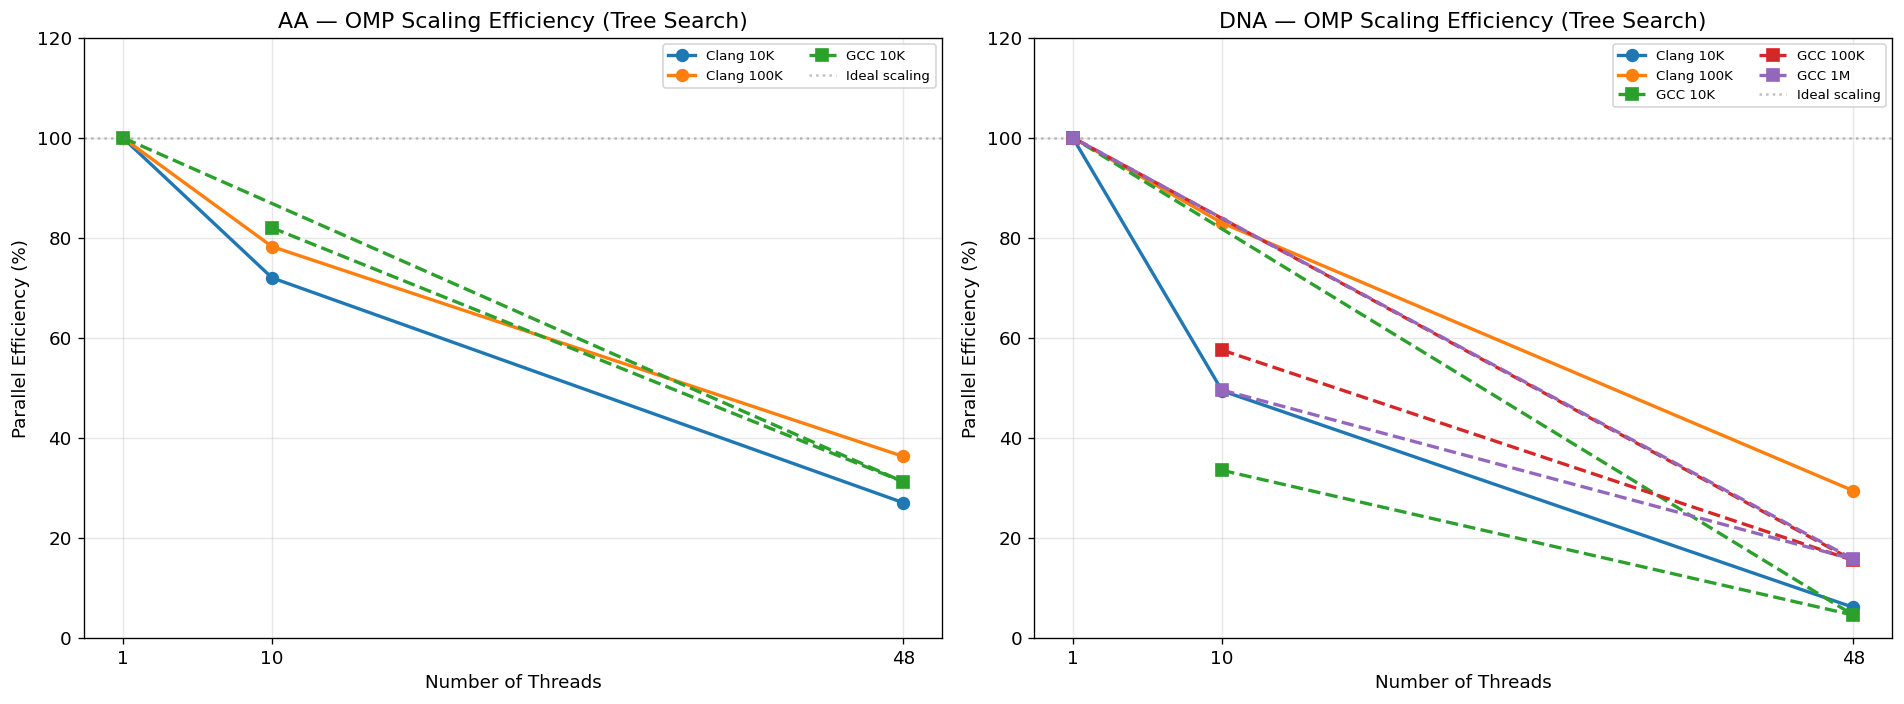

In [18]:
# For each data_type+length+compiler, compute parallel efficiency vs 1-thread baseline
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, dtype in enumerate(['AA', 'DNA']):
    ax = axes[idx]
    df_sub = df_combined[df_combined['data_type'] == dtype].copy()
    
    for compiler in ['Clang', 'GCC']:
        for length in sorted(df_sub['length'].unique()):
            df_cfg = df_sub[(df_sub['compiler'] == compiler) & (df_sub['length'] == length)]
            baseline = df_cfg[df_cfg['exec_type'] == 'VANILA']['wall_treesearch_sec']
            if len(baseline) == 0:
                continue
            baseline = baseline.values[0]
            
            threads = []
            efficiencies = []
            for _, row in df_cfg.iterrows():
                t = row['threads']
                speedup = baseline / row['wall_treesearch_sec']
                efficiency = speedup / t * 100  # percent of ideal
                threads.append(t)
                efficiencies.append(efficiency)
            
            length_label = {10000: '10K', 100000: '100K', 1000000: '1M'}[length]
            ls = '-' if compiler == 'Clang' else '--'
            marker = 'o' if compiler == 'Clang' else 's'
            ax.plot(threads, efficiencies, marker=marker, linestyle=ls,
                   label=f'{compiler} {length_label}', linewidth=2, markersize=7)
    
    ax.axhline(y=100, color='gray', linestyle=':', alpha=0.5, label='Ideal scaling')
    ax.set_xlabel('Number of Threads')
    ax.set_ylabel('Parallel Efficiency (%)')
    ax.set_title(f'{dtype} — OMP Scaling Efficiency (Tree Search)')
    ax.legend(fontsize=8, ncol=2)
    ax.set_xticks([1, 10, 48])
    ax.grid(alpha=0.3)
    ax.set_ylim(0, 120)

plt.tight_layout()
plt.savefig('/Users/u7826985/Projects/Nvidia/poc-gpu-likelihood-calculation_analysis/2026_05_08_clang_outputs/fig07_omp_scaling_efficiency.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
# CSV for fig07: OMP scaling efficiency
rows = []
for dtype in ['AA', 'DNA']:
    df_sub = df_combined[df_combined['data_type'] == dtype]
    for compiler in ['Clang', 'GCC']:
        for length in sorted(df_sub['length'].unique()):
            df_cfg = df_sub[(df_sub['compiler'] == compiler) & (df_sub['length'] == length)]
            baseline = df_cfg[df_cfg['exec_type'] == 'VANILA']['wall_treesearch_sec']
            if len(baseline) == 0:
                continue
            baseline_val = baseline.values[0]
            for _, row in df_cfg.iterrows():
                t = int(row['threads'])
                speedup = baseline_val / row['wall_treesearch_sec']
                efficiency = speedup / t * 100
                ll = {10000: '10K', 100000: '100K', 1000000: '1M'}[length]
                rows.append({'Data Type': dtype, 'Compiler': compiler, 'Length': ll,
                             'Threads': t, 'TreeSearch (sec)': round(row['wall_treesearch_sec'], 1),
                             'Baseline 1T (sec)': round(baseline_val, 1),
                             'Speedup': round(speedup, 2),
                             'Efficiency (%)': round(efficiency, 1)})
df_fig07 = pd.DataFrame(rows).sort_values(['Data Type', 'Compiler', 'Length', 'Threads'])
df_fig07.to_csv(os.path.join(out_dir, 'fig07_omp_scaling.csv'), index=False)
print(f"Saved fig07_omp_scaling.csv ({len(df_fig07)} rows)")
df_fig07

Saved fig07_omp_scaling.csv (24 rows)


,Data Type,Compiler,Length,Threads,TreeSearch (sec),Baseline 1T (sec),Speedup,Efficiency (%)
3,AA,Clang,100K,1,42993.6,42993.6,1.00,100.0
4,AA,Clang,100K,10,5497.9,42993.6,7.82,78.2
5,AA,Clang,100K,48,2471.3,42993.6,17.40,36.2
0,AA,Clang,10K,1,3494.3,3494.3,1.00,100.0
1,AA,Clang,10K,10,485.6,3494.3,7.20,72.0
2,AA,Clang,10K,48,269.7,3494.3,12.96,27.0
8,AA,GCC,10K,1,6326.6,6326.6,1.00,100.0
6,AA,GCC,10K,10,771.9,6326.6,8.20,82.0
7,AA,GCC,10K,48,422.9,6326.6,14.96,31.2
12,DNA,Clang,100K,1,7351.6,7351.6,1.00,100.0


## 12. Summary table and CSV export

In [20]:
# Full summary table for all configs
out_dir = '/Users/u7826985/Projects/Nvidia/poc-gpu-likelihood-calculation_analysis/2026_05_08_clang_outputs'

# Build a comprehensive summary
summary_rows = []
for dtype in ['AA', 'DNA']:
    df_sub = df_combined[df_combined['data_type'] == dtype]
    
    for _, row in df_sub.iterrows():
        # Get GCC 1T baseline for this length
        b = df_sub[(df_sub['compiler'] == 'GCC') & (df_sub['exec_type'] == 'VANILA') & (df_sub['length'] == row['length'])]['wall_treesearch_sec']
        baseline = b.values[0] if len(b) > 0 else None
        speedup = baseline / row['wall_treesearch_sec'] if baseline and row['wall_treesearch_sec'] else None
        
        summary_rows.append({
            'Data Type': dtype,
            'Config': row['config_label'],
            'Length': row['length_label'],
            'Wall Total (min)': round(row['wall_total_min'], 1),
            'Tree Search (min)': round(row['wall_treesearch_min'], 1) if row['wall_treesearch_min'] else None,
            'Speedup vs GCC 1T': round(speedup, 2) if speedup else None,
            'Best LnL': row['best_lnl'],
        })

df_summary = pd.DataFrame(summary_rows)
df_summary = df_summary.sort_values(['Data Type', 'Length', 'Config'])

# Save
df_summary.to_csv(os.path.join(out_dir, 'full_comparison_summary.csv'), index=False)
df_combined.to_csv(os.path.join(out_dir, 'all_runs_combined.csv'), index=False)

# Also save the Clang vs GCC only comparison
summary_cg = df_speedup[['data_type', 'exec_type', 'length_label', 
                       'clang_wall', 'gcc_wall', 'speedup_total',
                       'clang_treesearch', 'gcc_treesearch', 'speedup_treesearch',
                       'clang_lnl', 'gcc_lnl', 'lnl_diff']].copy()
summary_cg.columns = ['Data Type', 'Exec Type', 'Length',
                    'Clang Wall (s)', 'GCC Wall (s)', 'Total Speedup',
                    'Clang TreeSearch (s)', 'GCC TreeSearch (s)', 'TreeSearch Speedup',
                    'Clang LnL', 'GCC LnL', 'LnL Diff']
summary_cg.to_csv(os.path.join(out_dir, 'clang_vs_gcc_comparison.csv'), index=False)

print("Files saved:")
print(f"  - {out_dir}/full_comparison_summary.csv")
print(f"  - {out_dir}/clang_vs_gcc_comparison.csv")
print(f"  - {out_dir}/all_runs_combined.csv")
print(f"\nFigures saved: fig01 through fig08")
print(f"\nNote: 2 runs incomplete (AA & DNA, 1M, 1-thread Clang vanilla — still running modelfinder)")
print()
df_summary

Files saved:
  - /Users/u7826985/Projects/Nvidia/poc-gpu-likelihood-calculation_analysis/2026_05_08_clang_outputs/full_comparison_summary.csv
  - /Users/u7826985/Projects/Nvidia/poc-gpu-likelihood-calculation_analysis/2026_05_08_clang_outputs/clang_vs_gcc_comparison.csv
  - /Users/u7826985/Projects/Nvidia/poc-gpu-likelihood-calculation_analysis/2026_05_08_clang_outputs/all_runs_combined.csv

Figures saved: fig01 through fig08

Note: 2 runs incomplete (AA & DNA, 1M, 1-thread Clang vanilla — still running modelfinder)



,Data Type,Config,Length,Wall Total (min),Tree Search (min),Speedup vs GCC 1T,Best LnL
3,AA,Clang 10T,100K,143.5,91.6,NaN,-7.541977e+06
0,AA,Clang 1T,100K,1163.3,716.6,NaN,-7.541977e+06
6,AA,Clang 48T,100K,56.8,41.2,NaN,-7.541977e+06
11,AA,GCC 10T,100K,206.8,131.2,NaN,-7.541977e+06
12,AA,GCC 48T,100K,78.4,55.1,NaN,-7.541977e+06
16,AA,GPU H200,100K,22.8,16.5,NaN,-7.541977e+06
17,AA,GPU V100,100K,48.4,34.4,NaN,-7.541977e+06
4,AA,Clang 10T,10K,13.8,8.1,13.03,-8.073500e+05
1,AA,Clang 1T,10K,103.6,58.2,1.81,-8.073500e+05
7,AA,Clang 48T,10K,6.6,4.5,23.46,-8.073500e+05
